In [1]:
import numpy as np
import networkx as nx

from scipy.integrate import solve_ivp

from replicator_net import ODReplicatorNetwork

Nodes: 16, Edges: 24
Zones: [0, 3, 5, 10, 12, 15]
Directed OD pairs: 30
solve_ivp success: True
message: The solver successfully reached the end of the integration interval.


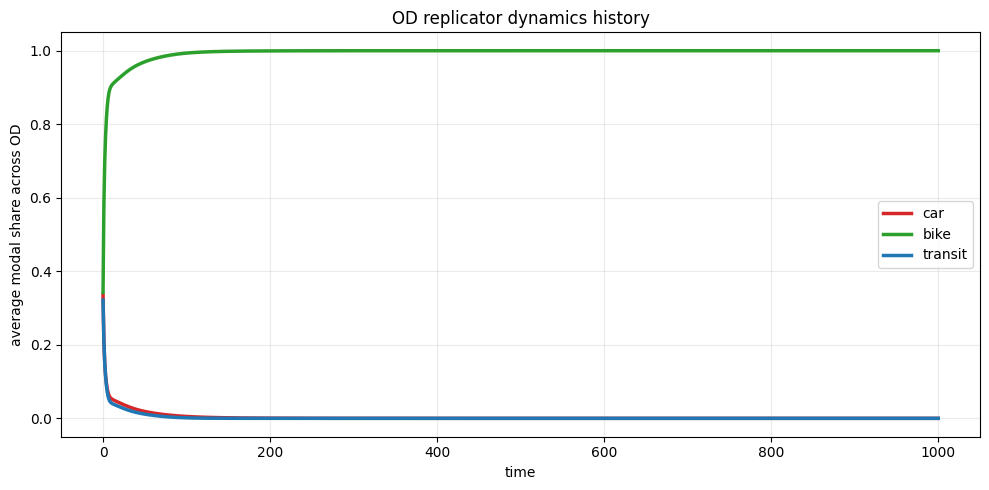

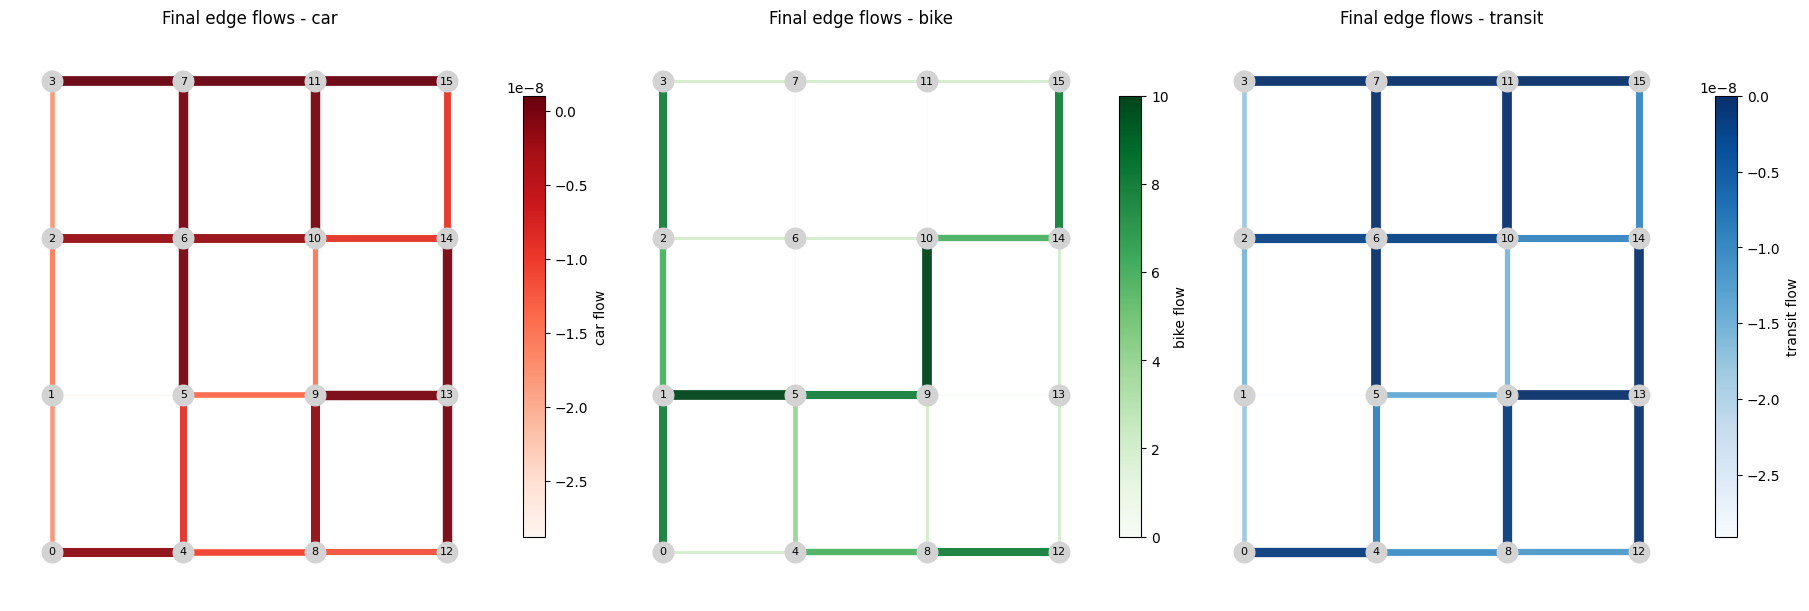


Final average modal shares:
car: -0.0000
bike: 1.0000
transit: -0.0000

Top 5 edges by final aggregate flow:
edge (9, 10) -> flow 10.0000
edge (1, 5) -> flow 10.0000
edge (8, 12) -> flow 8.0000
edge (2, 3) -> flow 8.0000
edge (5, 9) -> flow 8.0000


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# GRAPH GENERATION
# ============================================================

np.random.seed(1)

G_grid = nx.grid_2d_graph(4, 4)
G = nx.convert_node_labels_to_integers(
    G_grid,
    label_attribute="coord",
)

# keep geometric positions from original grid coordinates
pos = {n: data["coord"] for n, data in G.nodes(data=True)}

edges = list(G.edges())
E = len(edges)

print(f"Nodes: {G.number_of_nodes()}, Edges: {E}")

# Same graph for all modes
graphs = [
    G.copy(),  # car
    G.copy(),  # bike
    G.copy(),  # transit
]

mode_names = ["car", "bike", "transit"]
mode_colors = {"car": "tab:red", "bike": "tab:green", "transit": "tab:blue"}
mode_cmaps = {"car": plt.cm.Reds, "bike": plt.cm.Greens, "transit": plt.cm.Blues}
K = len(mode_names)

# ============================================================
# ZONES / OD PAIRS
# ============================================================

zones = [0, 3, 5, 10, 12, 15]
print(f"Zones: {zones}")
print(f"Directed OD pairs: {len(zones) * (len(zones) - 1)}")

# ============================================================
# EDGE PARAMETERS
# ============================================================

edge_lengths = np.random.uniform(1.0, 10.0, E)
# number of lanes per edge (integer 1..3)
n_lanes = np.random.randint(1, 4, size=E)
# capacity defined as length * number_of_lanes
edge_capacities = edge_lengths * n_lanes

car_speed = np.random.uniform(50.0, 50.0, E)
bike_speed = np.random.uniform(12.0, 12.0, E)
transit_speed = np.random.uniform(25.0, 25.0, E)

free_flow_speeds = np.column_stack([
    car_speed,
    bike_speed,
    transit_speed,
])

# interaction matrix (for congestion effects)
interaction_matrix = np.array([
    [ 5.0, 2.0, 1.0],
    [ 0.5, 2.0, 1.0],
    [ 1.0, 2.0, 1.0],
])

# ============================================================
# BUILD + SIMULATE
# ============================================================

model = ODReplicatorNetwork(
    multilayer_graphs=graphs,
    zones=zones,
    edge_lengths=edge_lengths,
    edge_capacities=edge_capacities,
    free_flow_speeds=free_flow_speeds,
    rho=0.1,
    interaction_matrix=interaction_matrix,
)

# random initial shares per OD, row-normalized
x0 = np.random.rand(model.N_od, model.K)
x0 = x0 / x0.sum(axis=1, keepdims=True)

t, X = model.simulate(
    x0,
    t_span=(0, 1000),
    n_steps=1000,
)

# ============================================================
# PLOT: DYNAMICS HISTORY
# ============================================================

# average modal share across all OD pairs over time
mode_history = X.mean(axis=1)  # shape (T, K)

plt.figure(figsize=(10, 5))
for m, name in enumerate(mode_names):
    plt.plot(
        t,
        mode_history[:, m],
        label=name,
        linewidth=2.5,
        color=mode_colors[name],
    )

plt.xlabel("time")
plt.ylabel("average modal share across OD")
plt.title("OD replicator dynamics history")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOT: GRAPH WITH FLOWS BY MODE (different colors)
# ============================================================

x_final = X[-1]

# flow per edge and mode
final_mode_flows = np.zeros((model.E, model.K))
for od in range(model.N_od):
    for m in range(model.K):
        share = x_final[od, m]
        path = model.paths[(od, m)]
        for e in path:
            final_mode_flows[e, m] += share

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for m, ax in enumerate(axes):
    mode_name = mode_names[m]
    edge_values = final_mode_flows[:, m]

    norm = plt.Normalize(vmin=edge_values.min(), vmax=edge_values.max() + 1e-12)
    edge_widths = 1.0 + 6.0 * norm(edge_values)

    nx.draw_networkx_nodes(
        G, pos=pos, node_size=220, node_color="lightgray", ax=ax
    )
    nx.draw_networkx_labels(
        G, pos=pos, font_size=8, ax=ax
    )
    nx.draw_networkx_edges(
        G,
        pos=pos,
        edgelist=edges,
        width=edge_widths,
        edge_color=edge_values,
        edge_cmap=mode_cmaps[mode_name],
        alpha=0.95,
        ax=ax,
    )

    sm = plt.cm.ScalarMappable(cmap=mode_cmaps[mode_name], norm=norm)
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label=f"{mode_name} flow")

    ax.set_title(f"Final edge flows - {mode_name}")
    ax.axis("off")

plt.show()

# ============================================================
# QUICK NUMERIC SUMMARY
# ============================================================

print("\nFinal average modal shares:")
for m, name in enumerate(mode_names):
    print(f"{name}: {mode_history[-1, m]:.4f}")

agg_flows = final_mode_flows.sum(axis=1)
top_edges = np.argsort(agg_flows)[-5:][::-1]
print("\nTop 5 edges by final aggregate flow:")
for idx in top_edges:
    print(f"edge {edges[idx]} -> flow {agg_flows[idx]:.4f}")

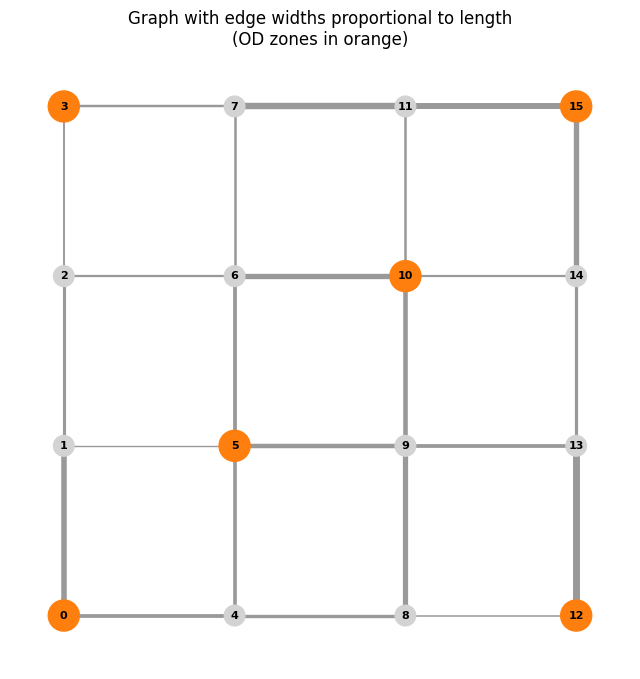

In [9]:
# plot of graph with edge widths proportional to their length
plt.figure(figsize=(8, 8))
edge_widths = 1.0 + 4.0 * (model.lengths - model.lengths.min()) / (model.lengths.max() - model.lengths.min() + 1e-12)

# Color nodes: OD zones in orange, others in gray
node_colors = ['tab:orange' if n in zones else 'lightgray' for n in G.nodes()]
node_sizes = [500 if n in zones else 220 for n in G.nodes()]

nx.draw_networkx_nodes(
    G, pos=pos, node_size=node_sizes, node_color=node_colors
)
nx.draw_networkx_labels(
    G, pos=pos, font_size=8, font_weight='bold'
)
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges,
    width=edge_widths,
    edge_color="gray",
    alpha=0.8,
)
plt.title("Graph with edge widths proportional to length\n(OD zones in orange)")
plt.axis("off")
plt.show()


# Analysis

Aggregate flow vs edge length — Pearson r = -0.1655, p = 0.44
Aggregate flow vs edge length — Spearman rho = -0.0855, p = 0.691


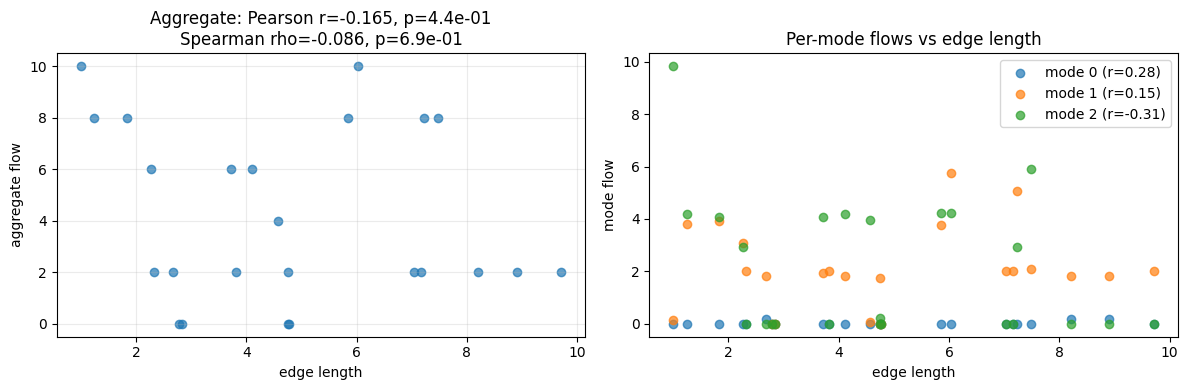

Mode 0: Pearson r=0.2793, p=0.186; Spearman rho=0.2234, p=0.294
Mode 1: Pearson r=0.1539, p=0.473; Spearman rho=0.1012, p=0.638
Mode 2: Pearson r=-0.3109, p=0.139; Spearman rho=-0.2836, p=0.179


In [ ]:
# Correlation analysis: edge lengths vs usage
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Ensure variables from previous cells are available
try:
    edge_lengths
    agg_flows
except NameError:
    raise RuntimeError("Run the previous cells first so that `edge_lengths` and `agg_flows` are defined.")

edge_lengths_arr = np.asarray(edge_lengths)
usage_arr = np.asarray(agg_flows)

# Basic checks
if edge_lengths_arr.shape[0] != usage_arr.shape[0]:
    raise ValueError("edge_lengths and agg_flows must have the same length.")

# Pearson (linear) and Spearman (rank) correlations for aggregate flow
pearson_r, pearson_p = pearsonr(edge_lengths_arr, usage_arr)
spearman_rho, spearman_p = spearmanr(edge_lengths_arr, usage_arr)

print(f'Aggregate flow vs edge length — Pearson r = {pearson_r:.4f}, p = {pearson_p:.3g}')
print(f'Aggregate flow vs edge length — Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.3g}')

# Per-mode correlations (if final_mode_flows is present)
mode_corrs = []
if 'final_mode_flows' in globals():
    F = np.asarray(final_mode_flows)
    if F.shape[0] == edge_lengths_arr.shape[0]:
        K = F.shape[1]
        for m in range(K):
            r, p = pearsonr(edge_lengths_arr, F[:, m])
            rho, sp = spearmanr(edge_lengths_arr, F[:, m])
            mode_corrs.append((r, p, rho, sp))
    else:
        print('final_mode_flows found but length mismatch; skipping per-mode correlations')
else:
    print('final_mode_flows not found; skipping per-mode correlations')

# Scatter plots
nplots = 1 + (1 if mode_corrs else 0)
fig, axes = plt.subplots(1, nplots, figsize=(6 * nplots, 4))
if nplots == 1:
    axes = [axes]

# Aggregate scatter
ax = axes[0]
ax.scatter(edge_lengths_arr, usage_arr, alpha=0.7)
ax.set_xlabel('edge length')
ax.set_ylabel('aggregate flow')
ax.set_title(f'Aggregate: Pearson r={pearson_r:.3f}, p={pearson_p:.1e}\nSpearman rho={spearman_rho:.3f}, p={spearman_p:.1e}')
ax.grid(alpha=0.25)

# Per-mode scatter matrix if available
if mode_corrs:
    ax = axes[1]
    cmap = plt.get_cmap('tab10')
    for m, (r, p, rho, sp) in enumerate(mode_corrs):
        vals = F[:, m]
        ax.scatter(edge_lengths_arr, vals, alpha=0.7, label=f'mode {m} (r={r:.2f})', color=cmap(m))
    ax.set_xlabel('edge length')
    ax.set_ylabel('mode flow')
    ax.set_title('Per-mode flows vs edge length')
    ax.legend()

plt.tight_layout()
plt.show()

# Print per-mode summary if available
if mode_corrs:
    for m, (r, p, rho, sp) in enumerate(mode_corrs):
        print(f'Mode {m}: Pearson r={r:.4f}, p={p:.3g}; Spearman rho={rho:.4f}, p={sp:.3g}')

# one mode trial

Single-mode network: Nodes: 16, Edges: 24
OD pairs: 30
Initial shares - mode 0: 1.0000 (should be 1.0)
solve_ivp success: True
message: The solver successfully reached the end of the integration interval.

Single-mode simulation complete.
Modal shares at t=0: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Modal shares at t_final: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]

Single-mode edge flows (aggregate):
  Mean: 4.1667
  Min: 0.0000
  Max: 10.0000


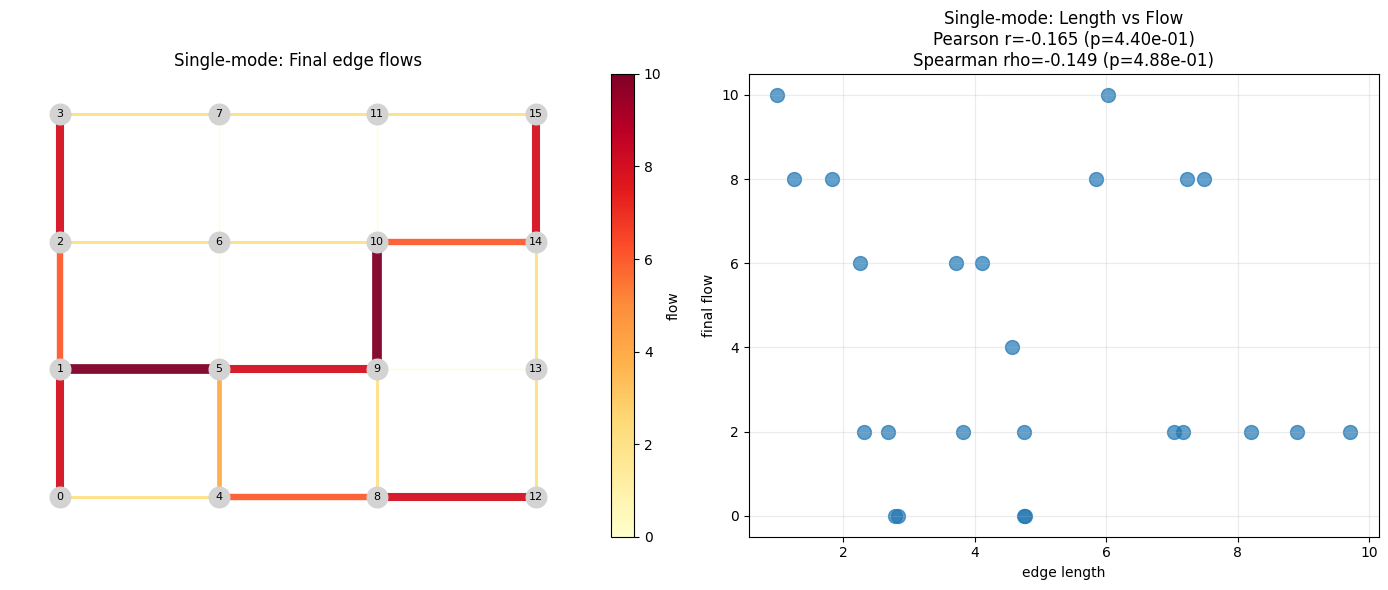


Network structure (betweenness) vs flows:
  Pearson r = -0.0519, p = 0.81
  Spearman rho = -0.2647, p = 0.211


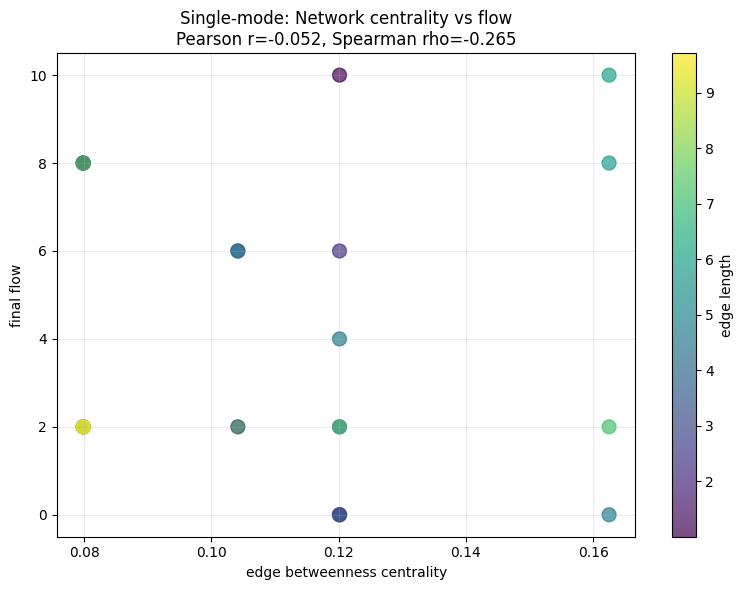

In [ ]:
# Single mode dynamics: how does network structure influence behavior?
# We'll run with just one mode to isolate network effects from mode competition

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(1)

# Use same graph but with ONE mode only
G_grid = nx.grid_2d_graph(4, 4)
G_single = nx.convert_node_labels_to_integers(
    G_grid,
    label_attribute="coord",
)

pos = {n: data["coord"] for n, data in G_single.nodes(data=True)}
edges_single = list(G_single.edges())
E_single = len(edges_single)

print(f"Single-mode network: Nodes: {G_single.number_of_nodes()}, Edges: {E_single}")

# Single mode
graphs_single = [G_single.copy()]

zones_single = [0, 3, 5, 10, 12, 15]

# Edge parameters (same as before, but only 1 mode)
edge_lengths_single = np.random.uniform(1.0, 10.0, E_single)
# number of lanes per edge (integer 1..3)
n_lanes_single = np.random.randint(1, 4, size=E_single)
edge_capacities_single = edge_lengths_single * n_lanes_single
free_flow_speed_single = np.random.uniform(50.0, 50.0, E_single)

# Single mode: no interaction matrix needed, just uniform speeds
free_flow_speeds_single = free_flow_speed_single.reshape(-1, 1)

# Build and simulate
model_single = ODReplicatorNetwork(
    multilayer_graphs=graphs_single,
    zones=zones_single,
    edge_lengths=edge_lengths_single,
    edge_capacities=edge_capacities_single,
    free_flow_speeds=free_flow_speeds_single,
    rho=0.1,
    interaction_matrix=None,  # not needed for single mode
)

# Initial condition: all traffic on single mode (trivial, so let's add small perturbation)
x0_single = np.random.rand(model_single.N_od, 1)
x0_single = x0_single / x0_single.sum(axis=1, keepdims=True)

print(f"OD pairs: {model_single.N_od}")
print(f"Initial shares - mode 0: {x0_single[:, 0].mean():.4f} (should be 1.0)")

t_single, X_single = model_single.simulate(
    x0_single,
    t_span=(0, 1000),
    n_steps=1000,
)

print("\nSingle-mode simulation complete.")
print(f"Modal shares at t=0: {X_single[0, :, 0]}")
print(f"Modal shares at t_final: {X_single[-1, :, 0]}")

# ============================================================
# PLOT: Edge flows in single mode
# ============================================================

x_final_single = X_single[-1]

# Compute final flows
final_flows_single = np.zeros(model_single.E)
for od in range(model_single.N_od):
    share = x_final_single[od, 0]
    path = model_single.paths[(od, 0)]
    for e in path:
        final_flows_single[e] += share

print(f"\nSingle-mode edge flows (aggregate):")
print(f"  Mean: {final_flows_single.mean():.4f}")
print(f"  Min: {final_flows_single.min():.4f}")
print(f"  Max: {final_flows_single.max():.4f}")

# Visualize flows
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: network with flow-based widths
norm = plt.Normalize(vmin=final_flows_single.min(), vmax=final_flows_single.max() + 1e-12)
edge_widths = 1.0 + 6.0 * norm(final_flows_single)

nx.draw_networkx_nodes(
    G_single, pos=pos, node_size=220, node_color="lightgray", ax=ax1
)
nx.draw_networkx_labels(
    G_single, pos=pos, font_size=8, ax=ax1
)
nx.draw_networkx_edges(
    G_single,
    pos=pos,
    edgelist=edges_single,
    width=edge_widths,
    edge_color=final_flows_single,
    edge_cmap=plt.cm.YlOrRd,
    alpha=0.95,
    ax=ax1,
)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
cbar = plt.colorbar(sm, ax=ax1, fraction=0.046, pad=0.04, label="flow")

ax1.set_title("Single-mode: Final edge flows")
ax1.axis("off")

# Right: correlation between edge length and flow
ax2.scatter(edge_lengths_single, final_flows_single, alpha=0.7, s=100)
from scipy.stats import pearsonr, spearmanr
r, p = pearsonr(edge_lengths_single, final_flows_single)
rho, sp = spearmanr(edge_lengths_single, final_flows_single)
ax2.set_xlabel("edge length")
ax2.set_ylabel("final flow")
ax2.set_title(f"Single-mode: Length vs Flow\nPearson r={r:.3f} (p={p:.2e})\nSpearman rho={rho:.3f} (p={sp:.2e})")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# TOPOLOGICAL ANALYSIS
# ============================================================

# Compute centrality measures and compare to flows
betweenness = nx.betweenness_centrality(G_single)
edge_betweenness = nx.edge_betweenness_centrality(G_single)

# Map edge betweenness to edge indices
edge_bet_values = np.array([
    edge_betweenness[edges_single[i]] 
    for i in range(E_single)
])

# Correlate network centrality with flows
r_bet, p_bet = pearsonr(edge_bet_values, final_flows_single)
rho_bet, sp_bet = spearmanr(edge_bet_values, final_flows_single)

print(f"\nNetwork structure (betweenness) vs flows:")
print(f"  Pearson r = {r_bet:.4f}, p = {p_bet:.3g}")
print(f"  Spearman rho = {rho_bet:.4f}, p = {sp_bet:.3g}")

# Visualize relationship
fig, ax = plt.subplots(figsize=(8, 6))
pc = ax.scatter(edge_bet_values, final_flows_single, alpha=0.7, s=100, c=edge_lengths_single, cmap='viridis')
ax.set_xlabel("edge betweenness centrality")
ax.set_ylabel("final flow")
ax.set_title(f"Single-mode: Network centrality vs flow\nPearson r={r_bet:.3f}, Spearman rho={rho_bet:.3f}")
cbar = plt.colorbar(pc, ax=ax, label="edge length")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
